# Lung Cancer Image Classification using Deep Learning

This notebook demonstrates a comparative analysis of deep learning models for lung cancer image classification. It's designed to be easy to follow and reproduce results.

**Models Compared:**
*   VGG-16 (as a baseline)
*   EfficientNetV2
*   ConvNeXt
*   Vision Transformer (ViT)

**Dataset:** CT Scan images classified into 4 categories:
*   Adenocarcinoma
*   Large Cell Carcinoma
*   Squamous Cell Carcinoma
*   Normal

## 📋 How to Run This Notebook

### One-time setup
1. **Dataset** — upload the `lung_dataset` folder to your Google Drive (e.g. directly under `My Drive/`). Expected structure:
   ```
   My Drive/
   └── lung_dataset/
       └── Data/
           ├── train/
           ├── valid/
           └── test/
   ```
2. **Path** — in **Section 2**, set `DATASET_PATH` to your `lung_dataset/Data` location.
3. **GPU** — `Runtime → Change runtime type → T4 GPU → Save`.

### Two ways to run
**A. Train from scratch.** Run **Sections 1–4**, then **5–8** to train and save each model, then **Section 9** to compare. On free Colab the ViT and the four-model comparison are memory-heavy, so prefer running Section 9 **cell by cell** (and ViT on a fresh kernel) rather than a single `Run all`.

**B. Already trained — just compare.** If the four `.keras` files are already in `My Drive/lung_models/`: run **Sections 1–4**, skip 5–8, then run **Section 9**. To *only* redraw the final chart (scores already saved in `comparison_results.json`), you need just **Section 1**, **Section 2**, and the **last cell of Section 9**.

> Trained models are saved to `My Drive/lung_models/`, and each score is written to `comparison_results.json` in that folder as soon as it is computed — so a kernel crash never loses finished results.

### Troubleshooting
- **`FileNotFoundError`** → re-check `DATASET_PATH` in Section 2 and the train/valid/test folder layout.
- **Kernel crash (out of memory)** → almost always ViT. Run it on a fresh kernel (Restart → Sections 1–4 → the ViT cell), and lower `VIT_BATCH` to 2 or 1 if needed.

## 1. Install & Import

Installs `keras-hub` (the TensorFlow-native Vision Transformer) and imports **every** library the notebook uses. All imports live in this single cell, so later sections assume it has already run — always start here after a fresh kernel. GPU memory growth is enabled here too, so TensorFlow grows VRAM on demand instead of grabbing it all up front.

In [1]:
# Keras-native ViT via keras-hub (TF-compatible, pretrained ImageNet weights)
!pip install -q --upgrade keras-hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.29.1 which is incompatible.


In [ ]:
# ---- Standard library ----
import os
import gc
import json
import warnings
warnings.filterwarnings('ignore')

# ---- Scientific / plotting ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Deep learning ----
import tensorflow as tf
import keras
import keras_hub  # TF-native ViT-B/16 (pretrained ImageNet); installed in the cell above

# Let TF grow GPU memory on demand instead of grabbing it all up front.
# Must run before any GPU op, so it lives here in the import cell.
for _gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      GlobalAveragePooling2D, Input, LayerNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.applications import VGG16, EfficientNetV2B0, ConvNeXtTiny

# ---- Metrics ----
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score as sk_f1

# ---- Colab ----
from google.colab import drive

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


## 2. Mount Google Drive & Configure Paths

Connects the notebook to Google Drive, then sets where the dataset lives (`DATASET_PATH`) and where models are saved (`SAVE_DIR`). **This is the one cell you may need to edit.** It verifies that the `train` / `valid` / `test` folders exist and stops early with a clear message if anything is missing or the path is wrong.

In [3]:
drive.mount('/content/drive')

# ============================================================
# 📁 CONFIGURE YOUR DATASET PATH HERE
# Change DATASET_PATH if your folder is in a different location.
# Example: "/content/drive/MyDrive/projects/lung_dataset/Data"
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/lung_dataset/Data"  # ← CHANGE IF NEEDED

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VALID_PATH = os.path.join(DATASET_PATH, "valid")
TEST_PATH  = os.path.join(DATASET_PATH, "test")
SAVE_DIR   = "/content/drive/MyDrive/lung_models"

os.makedirs(SAVE_DIR, exist_ok=True)

# ---- Verify paths ----
print("Checking dataset structure...\n")
all_ok = True
for split, path in [("train", TRAIN_PATH), ("valid", VALID_PATH), ("test", TEST_PATH)]:
    if not os.path.exists(path):
        print(f"❌  {split}: NOT FOUND at {path}")
        all_ok = False
    else:
        classes = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
        total   = sum(len(os.listdir(os.path.join(path, c))) for c in classes)
        print(f"✅  {split:6s}: {total:4d} images | {len(classes)} classes found")

if not all_ok:
    raise FileNotFoundError(
        "\n\n⚠️  Dataset not found. Please:\n"
        "  1. Upload 'lung_dataset' folder to your Google Drive\n"
        "  2. Update DATASET_PATH above to match your folder location\n"
        "  3. Re-run this cell"
    )
else:
    print("\n✅  All paths verified. Ready to train!")


Mounted at /content/drive
Checking dataset structure...

✅  train :  613 images | 4 classes found
✅  valid :   72 images | 4 classes found
✅  test  :  315 images | 4 classes found

✅  All paths verified. Ready to train!


## 3. Data Pipeline

Sets the image size, batch size, and class names, and builds the train / validation / test data loaders. Training images get light augmentation (small rotations, shifts, flips) to reduce overfitting on this small dataset; validation and test images are left untouched.

> **Preprocessing differs per model.** The rescaled (÷255) loaders defined here are used by VGG-16 and ConvNeXt. EfficientNetV2 and ViT carry their own internal normalization, so they use **raw `[0,255]`** loaders defined inside their own sections. Feeding a model the wrong kind of input is a classic cause of silently-wrong accuracy.

In [4]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 4

train_datagen    = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 10,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    shear_range        = 0.1,
    horizontal_flip    = True,
    vertical_flip      = True,
    fill_mode          = 'nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, path, shuffle=True):
    return datagen.flow_from_directory(
        path,
        target_size = IMG_SIZE,
        class_mode  = 'categorical',
        batch_size  = BATCH_SIZE,
        shuffle     = shuffle
    )

train_gen = make_generator(train_datagen,    TRAIN_PATH, shuffle=True)
valid_gen = make_generator(val_test_datagen, VALID_PATH, shuffle=False)
test_gen  = make_generator(val_test_datagen, TEST_PATH,  shuffle=False)

CLASS_NAMES = list(train_gen.class_indices.keys())
FRIENDLY_LABELS = {
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib"       : "Adenocarcinoma",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa"    : "Large Cell Carcinoma",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa" : "Squamous Cell Carcinoma",
    "normal"                                            : "Normal"
}
print("Class mapping:", train_gen.class_indices)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Class mapping: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}


## 4. Shared Utilities

Helper functions reused across every model, defined once here:
- `f1_metric` — a custom F1 score tracked during training.
- `get_callbacks` — early stopping, best-weights checkpointing, and learning-rate reduction.
- `build_head` / `unfreeze_top_layers` — the shared classifier head and fine-tuning helper.
- `evaluate_model` — standard evaluation (accuracy, weighted F1, report, confusion matrix) for the CNNs.
- `evaluate_model_streamed` — a memory-frugal evaluator (streamed `tf.data`, small batches) used for ViT, which otherwise exhausts free-Colab RAM.

Run this section once; every model section below depends on it.

In [ ]:
def f1_metric(y_true, y_pred):
    tp     = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    pp     = K.sum(K.round(K.clip(y_true, 0, 1)))
    pred_p = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = tp / (pred_p + K.epsilon())
    recall    = tp / (pp     + K.epsilon())
    return 2 * precision * recall / (precision + recall + K.epsilon())

METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
    f1_metric
]

def get_callbacks(model_name):
    save_path = os.path.join(SAVE_DIR, f"{model_name}.keras")
    return [
        ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5,
                          min_lr=1e-7, verbose=1),
        ModelCheckpoint(save_path, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ]

def build_head(base_model):
    x   = base_model.output
    x   = GlobalAveragePooling2D()(x)
    x   = BatchNormalization()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.5)(x)
    x   = Dense(128, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=out)

def unfreeze_top_layers(base_model, n=20):
    base_model.trainable = True
    for layer in base_model.layers[:-n]:
        layer.trainable = False

def plot_history(history, model_name):
    metrics_to_plot = ['accuracy', 'loss', 'auc', 'precision', 'f1_metric']
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(25, 4))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight='bold')
    for ax, m in zip(axes, metrics_to_plot):
        if m in history.history:
            ax.plot(history.history[m],          label='train')
            ax.plot(history.history[f'val_{m}'], label='val', linestyle='--')
            ax.set_title(m.capitalize())
            ax.set_xlabel('Epoch')
            ax.legend()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, gen, model_name):
    gen.reset()
    y_pred_probs = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = gen.classes

    acc  = accuracy_score(y_true, y_pred)
    f1   = sk_f1(y_true, y_pred, average='weighted')
    prec = sk_precision(y_true, y_pred, average='weighted', zero_division=0)
    rec  = sk_recall(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f" {model_name}")
    print(f"{'='*50}")
    print(f" Test Accuracy      : {acc:.4f}")
    print(f" Weighted Precision : {prec:.4f}")
    print(f" Weighted Recall    : {rec:.4f}")
    print(f" Weighted F1        : {f1:.4f}")
    print(f"{'='*50}\n")

    target_names = [FRIENDLY_LABELS.get(c, c) for c in CLASS_NAMES]
    print(classification_report(y_true, y_pred, target_names=target_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

def evaluate_model_streamed(model, test_path, model_name, batch_size=4):
    """OOM-safe evaluation for memory-heavy models (e.g. ViT).
    Streams a tf.data test set and predicts in small batches instead of
    holding a legacy generator + full prediction pass in RAM. Predictions
    still go through model.predict(), so any built-in preprocessor (e.g.
    the keras-hub ViT normalizer) is applied. shuffle=False keeps the order
    deterministic so the labels stay aligned with the predictions."""
    ds = keras.utils.image_dataset_from_directory(
        test_path, image_size=IMG_SIZE, batch_size=batch_size,
        label_mode='categorical', shuffle=False
    )
    names  = ds.class_names
    y_pred = np.argmax(model.predict(ds.prefetch(1), verbose=1), axis=1)
    y_true = np.concatenate([np.argmax(yb.numpy(), axis=1) for _, yb in ds])

    acc  = accuracy_score(y_true, y_pred)
    f1   = sk_f1(y_true, y_pred, average='weighted')
    prec = sk_precision(y_true, y_pred, average='weighted', zero_division=0)
    rec  = sk_recall(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f" {model_name}")
    print(f"{'='*50}")
    print(f" Test Accuracy      : {acc:.4f}")
    print(f" Weighted Precision : {prec:.4f}")
    print(f" Weighted Recall    : {rec:.4f}")
    print(f" Weighted F1        : {f1:.4f}")
    print(f"{'='*50}\n")

    target_names = [FRIENDLY_LABELS.get(c, c) for c in names]
    print(classification_report(y_true, y_pred, target_names=target_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    del ds
    return {"model": model_name, "accuracy": float(acc), "precision": float(prec), "recall": float(rec), "f1": float(f1)}

all_results = {}
print("✅ Utilities ready.")

---
## 🔄 (Optional) Load Pre-Trained Models

A shortcut for when all four models are **already trained and saved** to Drive: this one cell reloads and evaluates them in a single pass, so you can skip Sections 5–8.

For a more crash-resistant evaluation on free Colab, prefer **Section 9** instead — it evaluates one model per cell and saves each score immediately. You can safely skip this cell during a normal from-scratch run; it simply does nothing if no saved models exist yet.

In [ ]:
# ============================================================
# ♻️ LOAD ALREADY-TRAINED MODELS  (optional convenience path)
# ============================================================

# Re-ensure variables are defined for a fresh session
SAVE_DIR = "/content/drive/MyDrive/lung_models"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def make_generator(datagen, path, shuffle=True):
    return datagen.flow_from_directory(
        path,
        target_size = IMG_SIZE,
        class_mode  = 'categorical',
        batch_size  = BATCH_SIZE,
        shuffle     = shuffle
    )

# -- EfficientNetV2 needs its own RAW (no-rescale) generator --
val_test_datagen_raw = ImageDataGenerator()
test_gen_eff = make_generator(val_test_datagen_raw, TEST_PATH, shuffle=False)

# -- Map each model to its saved file AND the correct test generator --
# (ViT is handled separately below via the OOM-safe streamed evaluator.)
LOAD_MAP = {
    "VGG-16"        : ("vgg16_lung_cancer.keras",          test_gen),
    "EfficientNetV2": ("efficientnetv2_lung_cancer.keras", test_gen_eff),
    "ConvNeXt"      : ("convnext_lung_cancer.keras",       test_gen),
    "ViT"           : ("vit_lung_cancer.keras",            None),
}

for name, (fname, gen) in LOAD_MAP.items():
    fpath = os.path.join(SAVE_DIR, fname)
    if not os.path.exists(fpath):
        print(f"⚠️ {name}: file not found at {fpath} — skipping")
        continue

    print(f"\n♻️ Loading {name} from {fname} ...")
    if name == "ViT":
        # ViT: load uncompiled, evaluate via the streamed (OOM-safe) path
        model = tf.keras.models.load_model(fpath, compile=False)
        all_results[name] = evaluate_model_streamed(model, TEST_PATH, name, batch_size=4)
    else:
        model = tf.keras.models.load_model(fpath, custom_objects={'f1_metric': f1_metric})
        all_results[name] = evaluate_model(model, gen, name)

    del model
    tf.keras.backend.clear_session()
    gc.collect()

print("\n✅ Finished loading & evaluating saved models.")


---
## 5. Model 1 — VGG-16 (Baseline)

A classic CNN, used here as the baseline. We load ImageNet weights, unfreeze only the **top 8 layers** (keeping most pretrained features fixed — a good choice for a small dataset), attach the shared head, and fine-tune at a low learning rate. Every model section follows the same three-cell rhythm: **build → train (saving the best weights) → quick evaluation.**

In [ ]:
base_vgg = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
unfreeze_top_layers(base_vgg, n=8)

model_vgg = build_head(base_vgg)
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=METRICS
)
model_vgg.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,89

 Total params: 14,881,476 (56.77 MB)

 Trainable params: 13,144,964 (50.14 MB)

 Non-trainable params: 1,736,512 (6.62 MB)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3205 - auc: 0.6011 - f1_metric: 0.2215 - loss: 1.4327 - precision: 0.4279 - recall: 0.1498
Epoch 1: val_accuracy improved from None to 0.33333, saving model to /content/drive/MyDrive/lung_models/vgg16_lung_cancer.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lung_models/vgg16_lung_cancer.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 219s 10s/step - accuracy: 0.3491 - auc: 0.6288 - f1_metric: 0.2392 - loss: 1.3810 - precision: 0.4516 - recall: 0.1599 - val_accuracy: 0.3333 - val_auc: 0.5205 - val_f1_metric: 0.0000e+00 - val_loss: 1.3818 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.4698 - auc: 0.7091 - f1_metric: 0.3232 - loss: 1.2350 - precision: 0.5646 - recall: 0.2303
Epoch 2: val_accuracy improved from 0.33333 to 0.40278, saving model to /content/drive/MyDrive/lung_models/vgg16_lung_cancer.keras

Epoch 2: finished sa

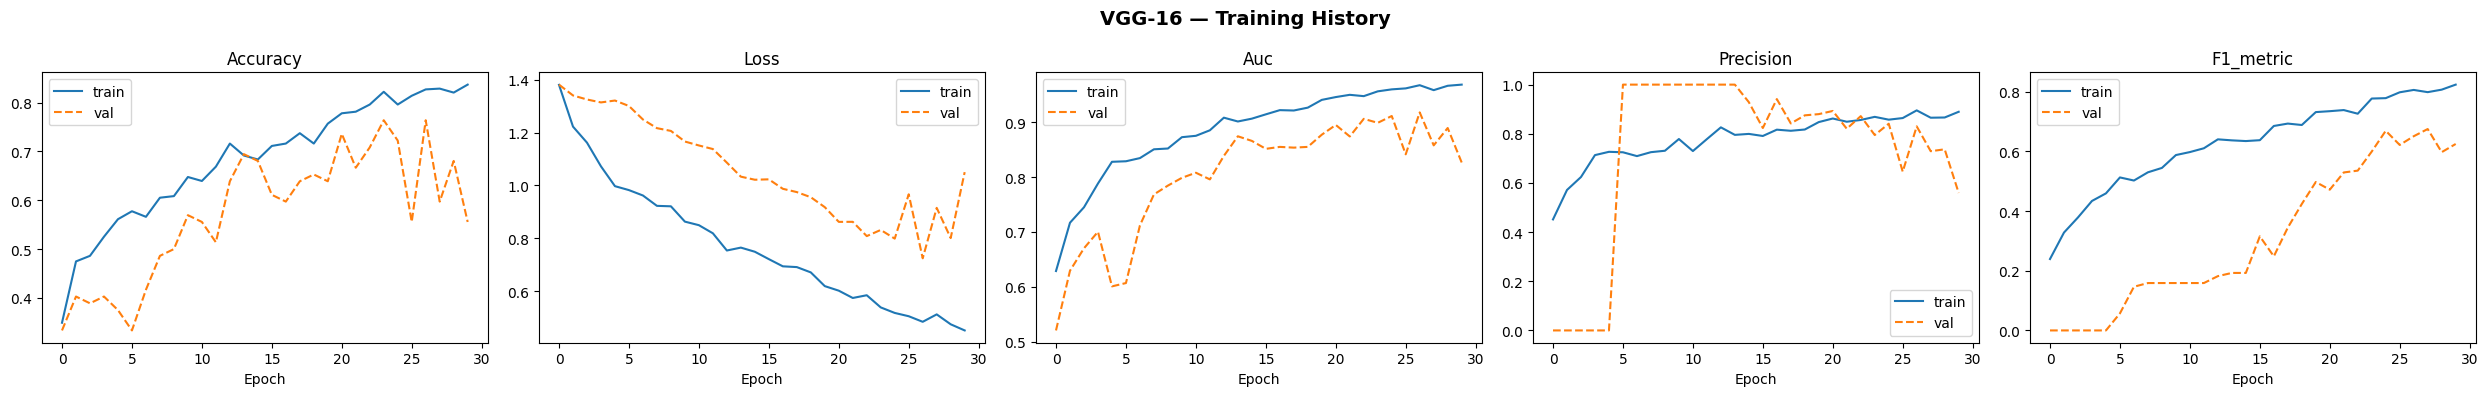

In [ ]:
history_vgg = model_vgg.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=30,
    callbacks=get_callbacks("vgg16_lung_cancer")
)
plot_history(history_vgg, "VGG-16")

10/10 ━━━━━━━━━━━━━━━━━━━━ 96s 11s/step

 VGG-16
 Test Accuracy : 0.7810
 Weighted F1   : 0.7791

                         precision    recall  f1-score   support

         Adenocarcinoma       0.69      0.82      0.75       120
   Large Cell Carcinoma       0.82      0.73      0.77        51
                 Normal       0.95      0.98      0.96        54
Squamous Cell Carcinoma       0.80      0.63      0.71        90

               accuracy                           0.78       315
              macro avg       0.82      0.79      0.80       315
           weighted avg       0.79      0.78      0.78       315



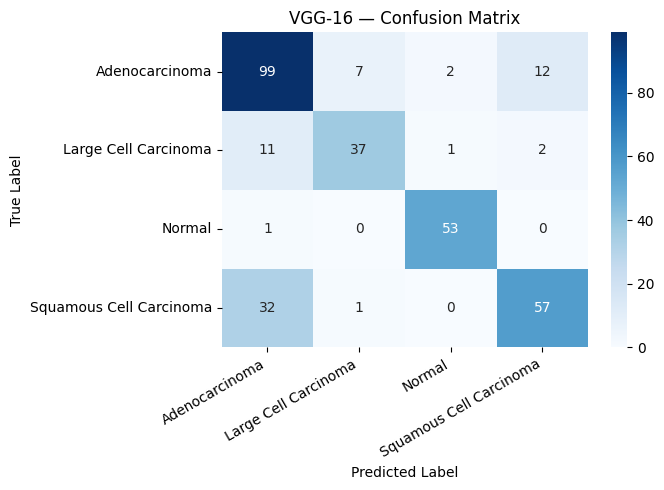

In [ ]:
results_vgg = evaluate_model(model_vgg, test_gen, "VGG-16")
all_results["VGG-16"] = results_vgg

---
## 6. Model 2 — EfficientNetV2

A newer, more parameter-efficient CNN family. Because it has its **own preprocessing built in**, this section defines raw (no-rescale) data loaders rather than reusing the rescaled ones from Section 3. The top 20 layers are unfrozen for fine-tuning.

In [ ]:
# EfficientNetV2 handles normalization internally — no rescale in datagen
train_datagen_eff    = ImageDataGenerator(
    rotation_range     = 10,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    shear_range        = 0.1,
    horizontal_flip    = True,
    vertical_flip      = True,
    fill_mode          = 'nearest'
)
val_test_datagen_raw = ImageDataGenerator()

train_gen_eff = make_generator(train_datagen_eff,    TRAIN_PATH, shuffle=True)
valid_gen_eff = make_generator(val_test_datagen_raw, VALID_PATH, shuffle=False)
test_gen_eff  = make_generator(val_test_datagen_raw, TEST_PATH,  shuffle=False)

base_eff = EfficientNetV2B0(
    input_shape           = (224, 224, 3),
    include_top           = False,
    weights               = 'imagenet',
    include_preprocessing = True
)
unfreeze_top_layers(base_eff, n=20)

model_eff = build_head(base_eff)
model_eff.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=METRICS
)
model_eff.summary()


In [ ]:
history_eff = model_eff.fit(
    train_gen_eff,
    validation_data=valid_gen_eff,
    epochs=30,
    callbacks=get_callbacks("efficientnetv2_lung_cancer")
)
plot_history(history_eff, "EfficientNetV2")

In [ ]:
results_eff = evaluate_model(model_eff, test_gen_eff, "EfficientNetV2")
all_results["EfficientNetV2"] = results_eff

---
## 7. Model 3 — ConvNeXt

A modern CNN that adopts several design ideas from transformers. It is heavier than VGG-16, so expect longer epochs — `EarlyStopping` automatically halts training once the validation loss stops improving.

In [ ]:
base_convnext = ConvNeXtTiny(
    input_shape           = (224, 224, 3),
    include_top           = False,
    weights               = 'imagenet',
    include_preprocessing = True
)
unfreeze_top_layers(base_convnext, n=20)

model_convnext = build_head(base_convnext)
model_convnext.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=METRICS
)
model_convnext.summary()


In [ ]:
history_convnext = model_convnext.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=30,
    callbacks=get_callbacks("convnext_lung_cancer")
)
plot_history(history_convnext, "ConvNeXt")

In [ ]:
results_convnext = evaluate_model(model_convnext, test_gen, "ConvNeXt")
all_results["ConvNeXt"] = results_convnext

---
### 🧹 Free Memory Before ViT

Training VGG-16, EfficientNetV2, and ConvNeXt leaves large model objects in RAM, and loading ViT-B/16 on top of them can crash the Colab kernel. This cell frees the CNN models first — their scores are already in `all_results` and their weights are saved to Drive, so nothing is lost. (Run it only on a single-session, train-everything pass; it is harmless to skip otherwise.)

In [ ]:
# Delete large CNN model objects if they exist (results are kept in all_results)
for _name in ['model_vgg', 'model_eff', 'model_convnext', 'model']:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass

keras.backend.clear_session()
gc.collect()
print("✅ Memory cleared. Safe to build ViT now.")


---
## 8. Model 4 — Vision Transformer (ViT)

Instead of convolutions, ViT splits the image into patches and relates them with self-attention. We use a TensorFlow-native **ViT-B/16 from keras-hub** with pretrained ImageNet weights. Three choices keep it stable and within free-Colab memory:
- **Head-only training** — the pretrained backbone is frozen; only the new classifier head learns.
- **Small batches + `tf.data`** — attention activations are memory-hungry, so it streams data in small batches instead of using the legacy generators.
- **Raw inputs** — keras-hub's ViT normalizes internally, so (like EfficientNetV2) it takes raw `[0,255]` images, **not** the rescaled ones.

In [ ]:
# ============================================================
# Lean ViT setup — uses tf.data (much lighter on RAM than
# ImageDataGenerator) and a small batch size to avoid the
# Colab out-of-memory kernel crash.
# ============================================================
BATCH_VIT = 8  # small batch = lower peak memory. Drop to 4 if it still crashes.

# tf.data pipelines. Images load as float32 in [0,255], which is exactly
# what the keras-hub ViT preprocessor expects (it normalizes internally).
train_ds_vit = keras.utils.image_dataset_from_directory(
    TRAIN_PATH, image_size=IMG_SIZE, batch_size=BATCH_VIT,
    label_mode='categorical', shuffle=True
).prefetch(1)

valid_ds_vit = keras.utils.image_dataset_from_directory(
    VALID_PATH, image_size=IMG_SIZE, batch_size=BATCH_VIT,
    label_mode='categorical', shuffle=False
).prefetch(1)

# -- Pick an available ViT-Base preset --
preferred = [
    "vit_base_patch16_224_imagenet",
    "vit_base_patch16_224_imagenet21k",
    "vit_base_patch16_224",
]
available = list(keras_hub.models.ViTImageClassifier.presets.keys())
print("Available ViT presets:", available)
preset_name = next((p for p in preferred if p in available), None)
if preset_name is None:
    preset_name = next((p for p in available if "base" in p), available[0])
print(f"Using preset: {preset_name}")

vit_classifier = keras_hub.models.ViTImageClassifier.from_preset(
    preset_name,
    num_classes = NUM_CLASSES,
    activation  = "softmax",
)

# Freeze backbone, train only the head (stable + low memory on small data)
vit_classifier.backbone.trainable = False

vit_classifier.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = METRICS
)
vit_classifier.summary()


In [ ]:
history_vit = vit_classifier.fit(
    train_ds_vit,
    validation_data=valid_ds_vit,
    epochs=30,
    callbacks=get_callbacks("vit_lung_cancer")
)
plot_history(history_vit, "ViT")

In [ ]:
# OOM-safe evaluation of the in-memory ViT — streams a tf.data test set
# and predicts in small batches (no legacy generator, no full-RAM pass).
all_results["ViT"] = evaluate_model_streamed(
    vit_classifier, TEST_PATH, "ViT", batch_size=BATCH_VIT
)

# free ViT + datasets before the comparison step
del vit_classifier, train_ds_vit, valid_ds_vit
keras.backend.clear_session()
gc.collect()


---
## 9. Model Comparison (crash-proof, incremental)
Loading four large models in one session can still exhaust Colab's RAM. To avoid losing
progress, each model is evaluated in its **own cell** and its score is **saved to a JSON
file on your Drive immediately**. If the kernel ever crashes, already-saved scores are kept.

**How to run:**
1. Run the helper cell below once (defines the save/eval helpers for the three CNNs).
2. Run the three CNN evaluation cells (VGG-16, EfficientNetV2, ConvNeXt) — any order.
3. Run the **ViT** cell. It is self-contained (streamed, OOM-safe) and does **not** need the
   helper — safest on its own fresh kernel: `Runtime → Restart`, run Sections 1–4, then
   just the ViT cell.
4. Run the final comparison cell to rank all four and name the winner.


In [6]:
# Re-defining path in case of kernel restart
SAVE_DIR = "/content/drive/MyDrive/lung_models"
RESULTS_PATH = os.path.join(SAVE_DIR, "comparison_results.json")

def _load_results():
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH) as f:
            return json.load(f)
    return {}

def _save_result(name, metrics):
    data = _load_results()
    data[name] = metrics
    with open(RESULTS_PATH, "w") as f:
        json.dump(data, f, indent=2)
    print(f"💾 Saved {name} -> {RESULTS_PATH}")

def eval_and_save(name, fname, needs_rescale, batch_size):
    """Load one CNN from disk, evaluate, persist its score, then free memory.
    (ViT is evaluated separately via the streamed OOM-safe cell below.)"""
    fpath = os.path.join(SAVE_DIR, fname)
    if not os.path.exists(fpath):
        print(f"⚠️  {fname} not found — skipping {name}.")
        return
    print(f"\n🔄 Evaluating {name} (batch={batch_size}) ...")

    # custom_objects lets load_model rebuild the f1_metric used at train time
    model = tf.keras.models.load_model(fpath, custom_objects={'f1_metric': f1_metric})

    # Setup correct generator based on model type
    datagen = ImageDataGenerator(rescale=1./255) if needs_rescale else ImageDataGenerator()
    gen = datagen.flow_from_directory(
        TEST_PATH,
        target_size=IMG_SIZE,
        class_mode='categorical',
        batch_size=batch_size,
        shuffle=False
    )

    res = evaluate_model(model, gen, name)
    _save_result(name, res)

    # Cleanup to prevent OOM
    del model, gen
    tf.keras.backend.clear_session()
    gc.collect()

print("✅ Helper ready. Now run the evaluation cells below.")
print("   Already saved so far:", list(_load_results().keys()) or "none")

✅ Helper ready. Now run the evaluation cells below.
   Already saved so far: ['ViT', 'VGG-16', 'EfficientNetV2', 'ConvNeXt']



🔄 Evaluating VGG-16 (batch=32) ...
Found 315 images belonging to 4 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 113s 11s/step

 VGG-16
 Test Accuracy : 0.6190
 Weighted F1   : 0.6193

                         precision    recall  f1-score   support

         Adenocarcinoma       0.62      0.58      0.60       120
   Large Cell Carcinoma       0.38      0.75      0.50        51
                 Normal       0.90      0.96      0.93        54
Squamous Cell Carcinoma       0.80      0.39      0.52        90

               accuracy                           0.62       315
              macro avg       0.67      0.67      0.64       315
           weighted avg       0.68      0.62      0.62       315



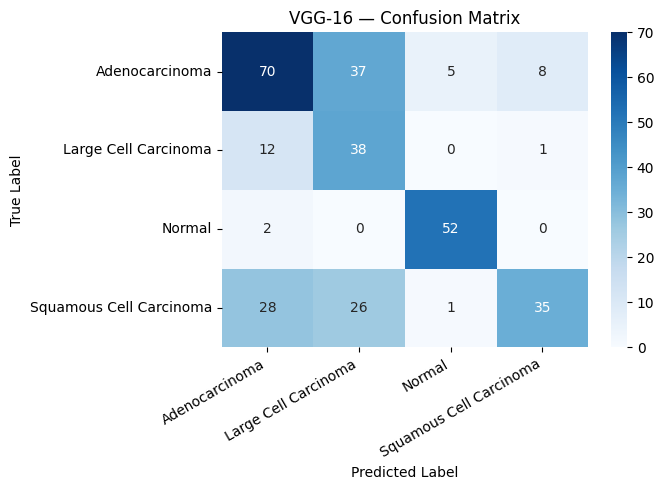

💾 Saved VGG-16 -> /content/drive/MyDrive/lung_models/comparison_results.json


In [7]:
# --- Evaluate VGG-16 ---
eval_and_save("VGG-16", "vgg16_lung_cancer.keras", needs_rescale=True, batch_size=32)


🔄 Evaluating EfficientNetV2 (batch=32) ...
Found 315 images belonging to 4 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step

 EfficientNetV2
 Test Accuracy : 0.6190
 Weighted F1   : 0.5555

                         precision    recall  f1-score   support

         Adenocarcinoma       0.50      0.97      0.66       120
   Large Cell Carcinoma       0.86      0.12      0.21        51
                 Normal       1.00      0.98      0.99        54
Squamous Cell Carcinoma       0.87      0.22      0.35        90

               accuracy                           0.62       315
              macro avg       0.81      0.57      0.55       315
           weighted avg       0.75      0.62      0.56       315



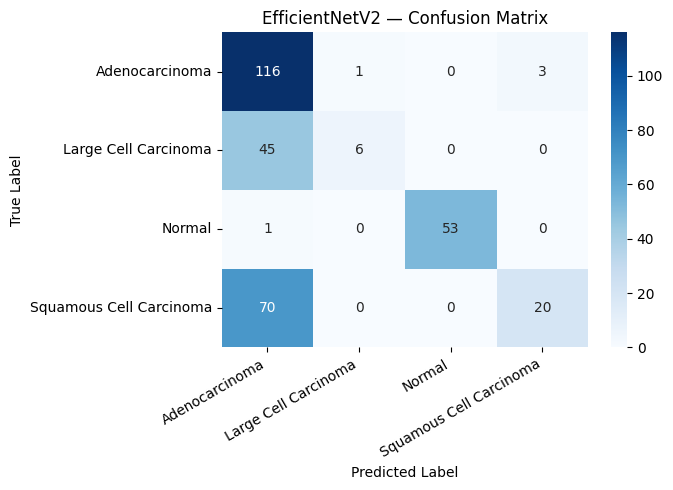

💾 Saved EfficientNetV2 -> /content/drive/MyDrive/lung_models/comparison_results.json


In [ ]:
# --- Evaluate EfficientNetV2 ---
eval_and_save("EfficientNetV2", "efficientnetv2_lung_cancer.keras", needs_rescale=False, batch_size=32)


🔄 Evaluating ConvNeXt (batch=32) ...
Found 315 images belonging to 4 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step

 ConvNeXt
 Test Accuracy : 0.5746
 Weighted F1   : 0.5039

                         precision    recall  f1-score   support

         Adenocarcinoma       0.50      0.90      0.65       120
   Large Cell Carcinoma       0.88      0.14      0.24        51
                 Normal       0.92      1.00      0.96        54
Squamous Cell Carcinoma       0.35      0.13      0.19        90

               accuracy                           0.57       315
              macro avg       0.66      0.54      0.51       315
           weighted avg       0.59      0.57      0.50       315



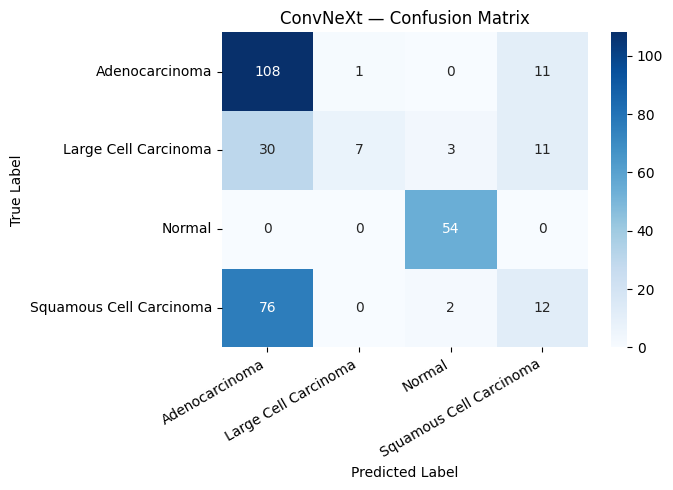

💾 Saved ConvNeXt -> /content/drive/MyDrive/lung_models/comparison_results.json


In [ ]:
# --- Evaluate ConvNeXt ---
eval_and_save("ConvNeXt", "convnext_lung_cancer.keras", needs_rescale=True, batch_size=32)

Loading ViT (compile=False)...
Found 315 files belonging to 4 classes.
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step

 ViT
 Test Accuracy : 0.5873
 Weighted F1   : 0.5565

                         precision    recall  f1-score   support

         adenocarcinoma       0.50      0.80      0.62       120
   large.cell.carcinoma       0.52      0.22      0.31        51
                 Normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.51      0.28      0.36        90

               accuracy                           0.59       315
              macro avg       0.63      0.57      0.57       315
           weighted avg       0.59      0.59      0.56       315



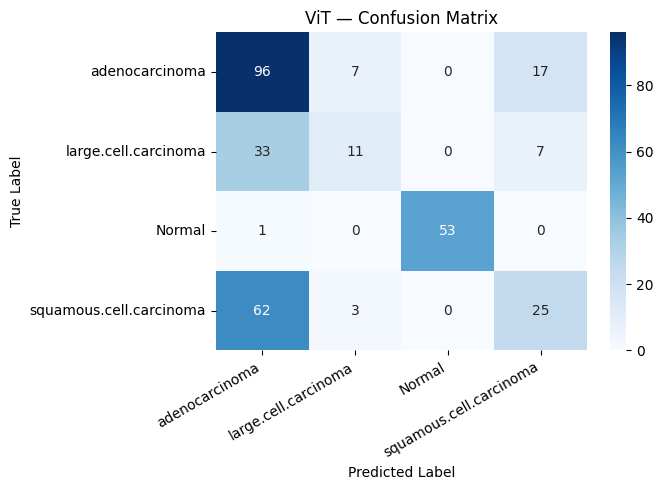

💾 Saved ViT → /content/drive/MyDrive/lung_models/comparison_results.json


0

In [ ]:
# ============================================================
# Evaluate ViT — self-contained & OOM-safe (streamed tf.data).
# Does NOT need the Section 9 helper cell. Safest on a FRESH kernel:
#   Runtime → Restart → run Sections 1–4 → run this cell.
# If it still crashes: lower VIT_BATCH to 2 or 1; if that fails too,
# the kernel is out of system RAM — wrap the eval call in
#   with tf.device('/CPU:0'):
# to run it on CPU using the full system memory (slower, but fine here).
# ============================================================
SAVE_DIR     = "/content/drive/MyDrive/lung_models"
RESULTS_PATH = os.path.join(SAVE_DIR, "comparison_results.json")
VIT_FILE     = os.path.join(SAVE_DIR, "vit_lung_cancer.keras")
VIT_BATCH    = 4   # drop to 2 or 1 if it still crashes

print("Loading ViT (compile=False)...")
vit = tf.keras.models.load_model(VIT_FILE, compile=False)

res = evaluate_model_streamed(vit, TEST_PATH, "ViT", batch_size=VIT_BATCH)

# Merge into the shared results file (same schema as the other three models)
results = {}
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        results = json.load(f)
results["ViT"] = res
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)
print(f"💾 Saved ViT → {RESULTS_PATH}")

del vit
keras.backend.clear_session()
gc.collect()


In [ ]:
# --- Final comparison — standalone (reads all four scores from the JSON file) ---
RESULTS_PATH = "/content/drive/MyDrive/lung_models/comparison_results.json"
with open(RESULTS_PATH) as f:
    results = json.load(f)

df_results = pd.DataFrame(results).T.reset_index(drop=True)
df_results = df_results.sort_values('accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*65)
print(" MODEL COMPARISON SUMMARY")
print("="*65)
print(df_results[['model', 'accuracy', 'precision', 'recall', 'f1']].to_string(index=False))
print("="*65)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Model Comparison — Test Set", fontsize=14, fontweight='bold')
colors      = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
model_names = df_results['model'].tolist()

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
titles          = ['Test Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1 Score']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals = df_results[metric].astype(float).tolist()
    ax.bar(model_names, vals, color=colors[:len(model_names)])
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

best = df_results.iloc[0]
print(f"\n✅ Best model: {best['model']}  "
      f"(Test Accuracy = {float(best['accuracy']):.4f}, "
      f"Weighted Precision = {float(best['precision']):.4f}, "
      f"Weighted Recall = {float(best['recall']):.4f}, "
      f"Weighted F1 = {float(best['f1']):.4f})")


---
## 10. Save the Best Model (VGG-16)

Section 9 identified **VGG-16** as the top performer, so it's the only model we deploy.

VGG-16 is a plain Keras model with **no custom layers**, so unlike the transformer
models it serializes cleanly. We just save the whole model with `model.save(...)` and
reload it directly — no architecture rebuild needed.

We also persist the **class order** straight from `train_gen.class_indices`. Since
`flow_from_directory` sorts class folders alphabetically, that ordering *is* the mapping
the model learned; hard-coding labels in the wrong order would silently swap predictions.

In [ ]:
import os, json

BEST_MODEL_NAME = "vgg16_lung_cancer"
MODEL_PATH      = f"{BEST_MODEL_NAME}.keras"
LABELS_PATH     = f"{BEST_MODEL_NAME}_labels.json"

# 1) Save the full trained model (architecture + weights)
model_vgg.save(MODEL_PATH)
print(f"\u2705 Model saved \u2192 {MODEL_PATH}")

# 2) Save the class order EXACTLY as the generator produced it
#    train_gen.class_indices -> {folder_name: index}; sort by index for model order
class_indices = train_gen.class_indices
CLASS_NAMES   = [name for name, idx in sorted(class_indices.items(), key=lambda kv: kv[1])]
with open(LABELS_PATH, "w") as f:
    json.dump(CLASS_NAMES, f)

print(f"\u2705 Class order saved \u2192 {LABELS_PATH}")
print("Classes (in model output order):", CLASS_NAMES)

✅ Model saved → vgg16_lung_cancer.keras
✅ Class order saved → vgg16_lung_cancer_labels.json
Classes (in model output order): ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


## 11. Deployment — Gradio Web App

A single-model classifier: the user uploads a chest CT scan and gets the predicted
lung-cancer category with confidence scores. No model selection is exposed to the user —
only the best model (VGG-16) runs behind the scenes, exactly as planned.

The cells below are **self-contained**: they reuse `model_vgg` if it's still in memory,
otherwise they load the saved `.keras` file — so deployment also works after a Colab
runtime restart without retraining.


In [ ]:
# Install Gradio (Colab)
!pip install -q gradio

In [ ]:
# \u2500\u2500 Load the model for inference \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
from tensorflow.keras.models import load_model
import numpy as np, json, os

BEST_MODEL_NAME = "vgg16_lung_cancer"
MODEL_PATH      = f"{BEST_MODEL_NAME}.keras"
LABELS_PATH     = f"{BEST_MODEL_NAME}_labels.json"

# Resolve class names (model output order)
try:
    CLASS_NAMES
except NameError:
    if os.path.exists(LABELS_PATH):
        with open(LABELS_PATH) as f:
            CLASS_NAMES = json.load(f)
    else:  # last-resort fallback: alphabetical = Keras default ordering
        CLASS_NAMES = sorted(os.listdir(os.path.join(DATASET_PATH, "train")))

# Prefer the in-memory model; otherwise load the saved .keras file
try:
    model = model_vgg
    print("\u2705 Using in-memory model_vgg (trained this session).")
except NameError:
    model = load_model(MODEL_PATH)
    print(f"\u2705 Loaded model from {MODEL_PATH}.")

print("Classes (model output order):", CLASS_NAMES)

✅ Using in-memory model_vgg (trained this session).
Classes (model output order): ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [ ]:
# \u2500\u2500 Preprocessing + prediction (must match training) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
def prettify(folder_name):
    """Turn raw dataset folder names into clean display labels."""
    n = folder_name.lower()
    if "adeno"    in n: return "Adenocarcinoma"
    if "large"    in n: return "Large Cell Carcinoma"
    if "squamous" in n: return "Squamous Cell Carcinoma"
    if "normal"   in n: return "Normal (No Cancer)"
    return folder_name

PRETTY = [prettify(c) for c in CLASS_NAMES]

def predict(image):
    if image is None:
        return None
    # Same pipeline as the training generator: RGB, 224x224, scale to [0,1]
    img = image.convert("RGB").resize((224, 224))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)              # (1, 224, 224, 3)
    preds = model.predict(arr, verbose=0)[0]       # (num_classes,)
    return {PRETTY[i]: float(preds[i]) for i in range(len(PRETTY))}

In [ ]:
# \u2500\u2500 Build & launch the Gradio app \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
import gradio as gr

TITLE = "\U0001FAC1 Lung Cancer CT Scan Classifier"
DESCRIPTION = (
    "Upload a chest CT scan to classify it into one of four categories: "
    "Adenocarcinoma, Large Cell Carcinoma, Squamous Cell Carcinoma, or Normal. "
    "Powered by a fine-tuned VGG-16 convolutional neural network.\n\n"
    "\u26A0\uFE0F **For educational/demonstration purposes only \u2014 not a medical "
    "diagnostic tool.** Always consult a qualified radiologist or physician."
)

# Optionally seed the UI with one example image per class from the test set
examples = []
test_dir = os.path.join(DATASET_PATH, "test")
if os.path.isdir(test_dir):
    for cls in sorted(os.listdir(test_dir)):
        cls_dir = os.path.join(test_dir, cls)
        if os.path.isdir(cls_dir):
            imgs = [f for f in os.listdir(cls_dir)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))]
            if imgs:
                examples.append(os.path.join(cls_dir, imgs[0]))

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Chest CT Scan"),
    outputs=gr.Label(num_top_classes=4, label="Prediction"),
    title=TITLE,
    description=DESCRIPTION,
    examples=examples if examples else None,
)

# share=True gives a public link you can open / submit for the assessment demo
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1cc216d2241934b441.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Deploy ke Hugging Face Spaces

In [ ]:
from huggingface_hub import login
login()

In [ ]:
!pip install -q huggingface_hub

# 1) Tulis app.py
app_code = r'''
import gradio as gr
import numpy as np, json
from tensorflow.keras.models import load_model

model = load_model("vgg16_lung_cancer.keras")
with open("vgg16_lung_cancer_labels.json") as f:
    CLASS_NAMES = json.load(f)

def prettify(n):
    n = n.lower()
    if "adeno" in n: return "Adenocarcinoma"
    if "large" in n: return "Large Cell Carcinoma"
    if "squamous" in n: return "Squamous Cell Carcinoma"
    if "normal" in n: return "Normal (No Cancer)"
    return n
PRETTY = [prettify(c) for c in CLASS_NAMES]

def predict(image):
    if image is None: return None
    img = image.convert("RGB").resize((224, 224))
    arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, 0)
    preds = model.predict(arr, verbose=0)[0]
    return {PRETTY[i]: float(preds[i]) for i in range(len(PRETTY))}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Chest CT Scan"),
    outputs=gr.Label(num_top_classes=4, label="Prediction"),
    title="🫁 Lung Cancer CT Scan Classifier",
    description=("Upload a chest CT scan to classify it as Adenocarcinoma, "
                 "Large Cell Carcinoma, Squamous Cell Carcinoma, or Normal. "
                 "Powered by a fine-tuned VGG-16.\n\n"
                 "⚠️ For educational/demo purposes only — not a diagnostic tool."),
)
demo.launch()
'''
open("app.py", "w").write(app_code)

# 2) Tulis requirements.txt
open("requirements.txt", "w").write("gradio\ntensorflow-cpu\npillow\nnumpy\n")

# 3) Buat Space + upload semua file
from huggingface_hub import create_repo, upload_file

HF_USER    = "Suizen"        # <-- username HF kamu
SPACE_NAME = "lung-cancer-classifier"
repo_id = f"{HF_USER}/{SPACE_NAME}"

create_repo(repo_id, repo_type="space", space_sdk="gradio",
            exist_ok=True)

for fn in ["app.py", "requirements.txt",
           "vgg16_lung_cancer.keras", "vgg16_lung_cancer_labels.json"]:
    upload_file(path_or_fileobj=fn, path_in_repo=fn,
                repo_id=repo_id, repo_type="space")
    print("✅ uploaded", fn)

print(f"\n🚀 App sedang di-build di: https://huggingface.co/spaces/{repo_id}")

✅ uploaded app.py
✅ uploaded requirements.txt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vgg16_lung_cancer.keras     :   0%|          |  551kB /  165MB            

✅ uploaded vgg16_lung_cancer.keras
✅ uploaded vgg16_lung_cancer_labels.json

🚀 App sedang di-build di: https://huggingface.co/spaces/Suizen/lung-cancer-classifier


In [ ]:
from huggingface_hub import upload_file

with open("app.py") as f:
    code = f.read()
code = code.replace(
    'load_model("vgg16_lung_cancer.keras")',
    'load_model("vgg16_lung_cancer.keras", compile=False)'
)
with open("app.py", "w") as f:
    f.write(code)

upload_file(path_or_fileobj="app.py", path_in_repo="app.py",
            repo_id="Suizen/lung-cancer-classifier", repo_type="space")
print("✅ app.py diperbarui & di-upload ulang")

✅ app.py diperbarui & di-upload ulang
